In [1]:
%matplotlib inline
import os
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import json
from collections import defaultdict
import numpy as np
from plot_config import apply_plot_config

In [3]:
apply_plot_config()

In [4]:
class OpinionTrends(object):
    def __init__(self, filename: object):
        """
        :param model: The model object
        :param trends: The computed simulation trends
        """

        self.data = defaultdict(list)

        with open(filename) as file:
            old_iter = 0
            statuses = {}

            for id_row, l in enumerate(file):
                try:
                    l = json.loads(l)
                    iter = l["iteration"]
                except:
                    continue

                if iter == old_iter:
                    statuses = l["status"]
                else:
                    sts = {
                        k: sum(value == k for value in statuses.values())
                        for k in range(0, 7)
                    }
                    old_iter = iter
                    for k, v in sts.items():
                        self.data[k].append(v)

        for k, v in self.data.items():
            self.data[k] = [x / len(l["status"]) for x in self.data[k]]

    def plot(self, ax, limit=None):
        """
        Generates the plot

        :param filename: Output filename
        :param percentile: The percentile for the trend variance area
        """
                
        label = {
            0: "Strongly Disagree",
            1: "Disagree",
            2: "Mildly Disagree",
            3: "Neutral",
            4: "Mildly Agree",
            5: "Agree",
            6: "Strongly Agree",
        }
        for k in [0, 6, 1, 5, 2, 4, 3]:
            if limit is None:
                ax.plot(
                    range(0, len(self.data[k])),
                    self.data[k],
                    label=label[k],
                )
            else:
                ax.plot(
                    range(0, limit),
                    self.data[k][:limit],
                    label=label[k],
                )
        # Label the axes
        ax.set_xlabel("Iterations")  # X-axis label
        ax.set_ylabel("%Agents")  # Y-axis label
        ax.set_ylim(-0.01, 1.01)

In [17]:
class ShiftMatrix(object):
    # Private method to manipulate and process opinion shift data
    def _manipulate(self, f, accept, reject, total):
        data = json.load(open(f))  # Load JSON data from file `f`
        
        # Iterate through each key in the loaded data (each interaction entry)
        for k in data.keys():
            l = data[k]  # Get the interaction data for key `k`
            d_op = l[0]  # Discussant's opinion
            o_op = l[1]  # Opponent's opinion
            result = l[2]  # Interaction result (accept, reject, or ignore)

            # If the discussant and opponent have the same opinion, skip the interaction
            if d_op == o_op:
                continue

            total[d_op][o_op] += 1  # Increment total interactions for this opinion pair

            # Update the accept or reject matrices based on the interaction result
            if result == "accept":
                accept[d_op][o_op] += 1
            elif result == "reject":
                reject[d_op][o_op] += 1

        # Return the updated matrices
        return accept, reject, total

    def __init__(self, filename: object):
        """
        Initializes the ShiftMatrix object and processes data from one or more files.

        :param filename: A single file or a list of files containing interaction data.
        """
        self.data = {}  # Initialize an empty dictionary to store the processed data
        c = 0  # Unused counter variable

        # Initialize 7x7 matrices for accept, reject, and total counts, all set to 0
        accept = [
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ]
        reject = [
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ]
        total = [
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ]

        # If the filename is a list, process each file in the list
        if isinstance(filename, list):
            for f in filename:
                accept, reject, total = self._manipulate(f, accept, reject, total)
        else:
            # If it's a single file, process that file
            accept, reject, total = self._manipulate(filename, accept, reject, total)

        # Normalize the accept and reject matrices by dividing each element by the corresponding total count
        for i in range(len(total)):
            d = total[i]
            for j in range(len(d)):
                if d[j] > 0:
                    accept[i][j] /= d[j]
                    reject[i][j] /= d[j]

        # Store the normalized accept and reject matrices in the data dictionary
        self.data = {"accept": accept, "reject": reject}
    
    def get_data(self, d='accept'):
        return self.data[d]  
      
    # Method to plot the accept or reject matrix as a heatmap
    def plot(self, ax, d="accept"):
        """
        Generates the plot for the chosen matrix (accept or reject).

        :param filename: Optional output filename to save the plot.
        :param d: The matrix to plot, either 'accept' or 'reject'.
        """
                
        # Display the chosen matrix as a heatmap with a blue color map
        ax.matshow(self.data[d], cmap="Blues", extent=(0, 7, 7, 0))
        ax.grid(color="w", linestyle="-", linewidth=1, which="minor")  # Add grid lines

        # # Annotate the heatmap with the values for each matrix element
        # for (i, j), z in np.ndenumerate(self.data[d]):
        #     if i != j:  # Avoid annotating the diagonal (same opinion pairs)
        #         ax.text(
        #             j + 0.5,  # X position of the text (column)
        #             i + 0.5,  # Y position of the text (row)
        #             "{:0.1}".format(z),  # Format the value as a string with 2 decimals
        #             ha="center",  # Horizontal alignment
        #             va="center",  # Vertical alignment
        #             size=5,  # Text size
        #             alpha=1,  # Text opacity
        #             color="white"  # Text color
        #         )

        # Set major ticks for the x and y axes
        major_ticks = np.arange(0.5, 7.5, 1)
        ax.set_xticks(major_ticks)  # Set x-axis major ticks
        ax.set_yticks(major_ticks)  # Set y-axis major ticks

        # Set labels for the x and y axes
        ax.set_xticklabels(
            [
                "SD", "D", "MD", "N", "MA", "A", "SA",
            ],
            ha="center",  # Left-align the x-axis labels
            size=6,  # Label size
        )
        ax.set_yticklabels(
            [
                "SD", "D", "MD", "N", "MA", "A", "SA",
            ],
            size=6,  # Label size
            va="center",  # Center-align the y-axis labels
        )

        ax.xaxis.set_ticks_position("bottom")  # Set the x-axis ticks at the bottom
        ax.xaxis.set_tick_params(width=0)
        ax.yaxis.set_tick_params(width=0)
        
        # Label the axes
        ax.set_xlabel("Opponent")  # X-axis label
        ax.set_ylabel("Discussant")  # Y-axis label
        
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

In [18]:
path = "../../"

In [19]:
c = (1 / 2.54) / 10 

In [20]:
width = 170*c
height = 80*c

print(width, height)

6.692913385826771 3.149606299212598


# Codice figura 2

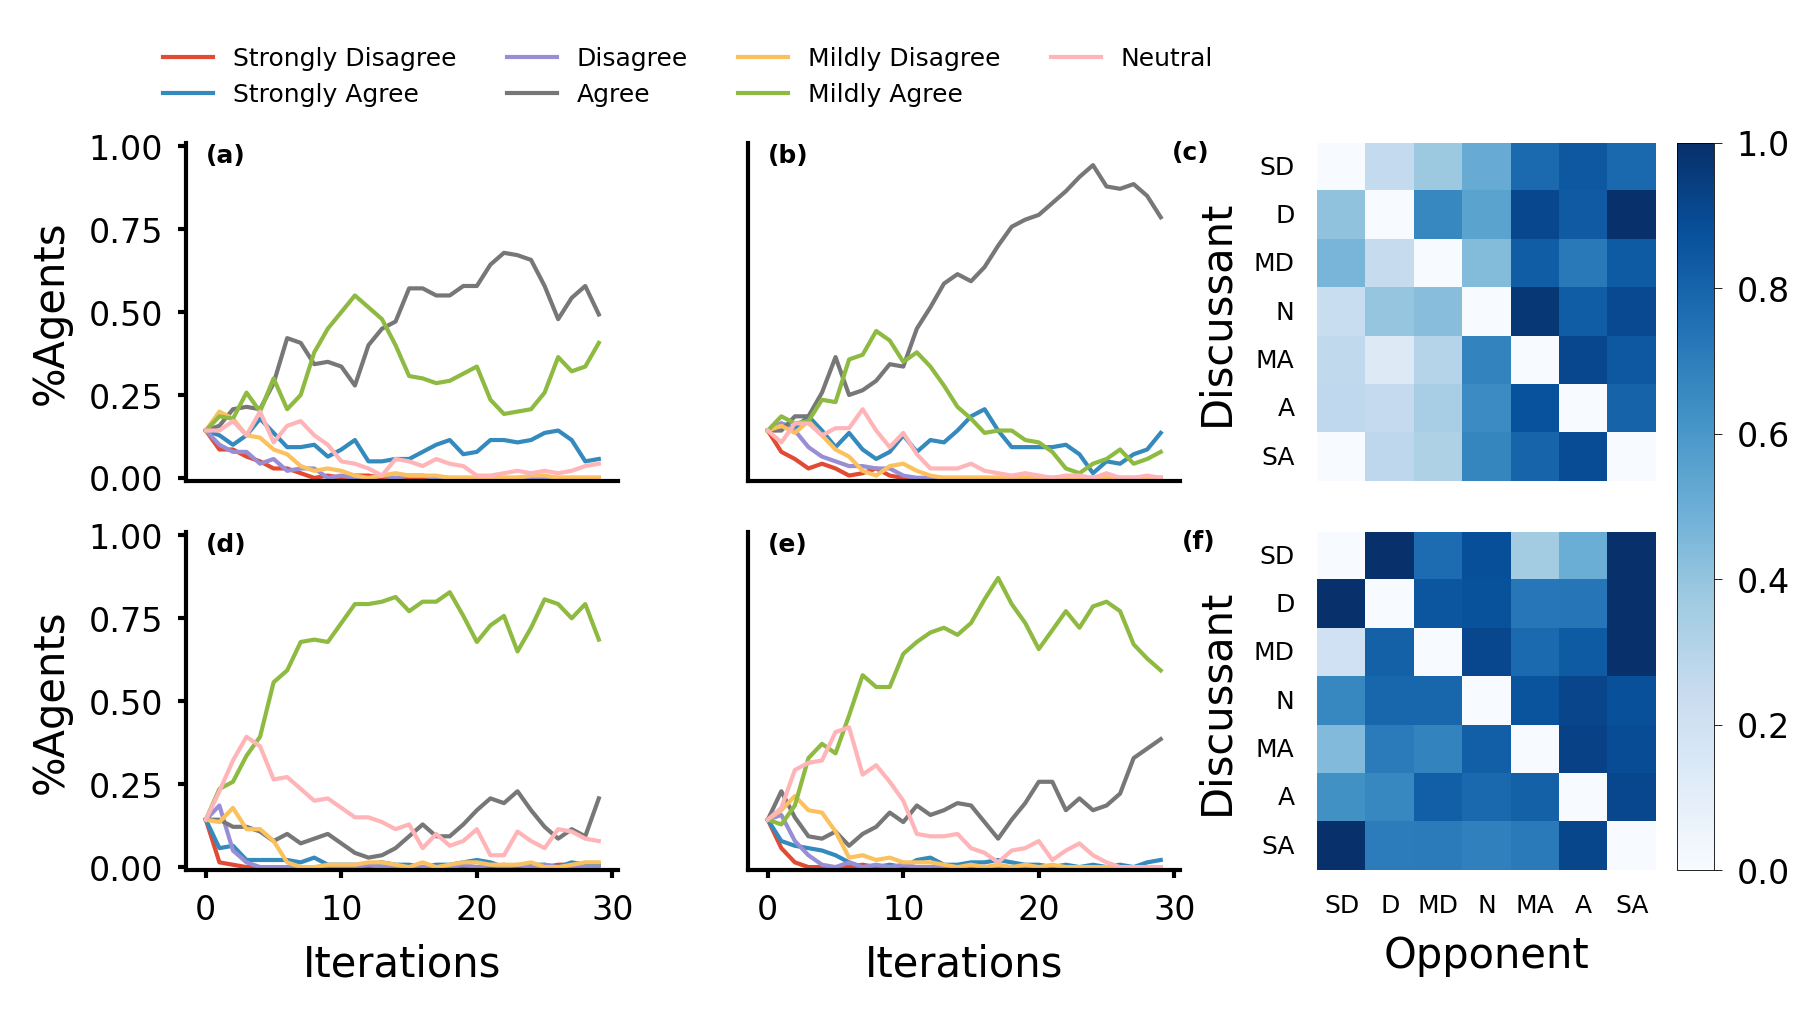

In [21]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Define the figure and GridSpec
fig = plt.figure(figsize=(width, height), dpi=300)
gs = GridSpec(2, 3, figure=fig, wspace=0.3, hspace=0.15)  # Adjust wspace for equal column spacing

# First row
ax1 = fig.add_subplot(gs[0, 0])
ot = OpinionTrends(path + f"results/theseus_same_mistral_0.jsonl")
ot.plot(ax=ax1, limit=30)
ax1.text(0.0, 0.95, '(a)', fontweight='bold', fontsize=6)
ax1.set_xlabel("")  # X-axis label
ax1.set_xticks([])

ax2 = fig.add_subplot(gs[0, 1])
ot = OpinionTrends(path + f"results/theseus_different_mistral_0.jsonl")
ot.plot(ax=ax2, limit=30)
ax2.text(0.0, 0.95, '(b)', fontweight='bold', fontsize=6)
ax2.set_xlabel("")  # X-axis label
ax2.set_ylabel("")  # Y-axis label
ax2.set_xticks([])
ax2.set_yticks([])

ax3 = fig.add_subplot(gs[0, 2])
sm = ShiftMatrix(f'../../results/shifts_data/theseus_same_mistral_balanced.json')
data = sm.get_data(d='accept')
sm.plot(d="accept", ax=ax3)
ax3.text(-0.43, 0.95, '(c)', fontweight='bold', fontsize=6, transform=ax3.transAxes)  # Add (c)
ax3.set_xlabel("")  # X-axis label
ax3.set_xticks([])  # Remove x-axis ticks

# Second row
ax4 = fig.add_subplot(gs[1, 0])
ot = OpinionTrends(path + f"results/theseus_same_llama3_0.jsonl")
ot.plot(ax=ax4, limit=30)
ax4.text(0.0, 0.95, '(d)', fontweight='bold', fontsize=6)

ax5 = fig.add_subplot(gs[1, 1])
ot = OpinionTrends(path + f"results/theseus_different_llama3_0.jsonl")
ot.plot(ax=ax5, limit=30)
ax5.text(0.0, 0.95, '(e)', fontweight='bold', fontsize=6)
ax5.set_ylabel("")
ax5.set_yticks([])

ax6 = fig.add_subplot(gs[1, 2])
sm = ShiftMatrix(f'../../results/shifts_data/theseus_same_llama3_balanced.json')
data = sm.get_data(d='accept')
sm.plot(d="accept", ax=ax6)
ax6.text(-0.4, 0.95, '(f)', fontweight='bold', fontsize=6, transform=ax6.transAxes)  # Add (f)

# Add a single colorbar for the last column
cax = ax6.get_images()[0]
cbar = plt.colorbar(cax, ax=[ax3, ax6], orientation="vertical", pad=0.05)
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.2)
cbar.ax.tick_params(labelsize=8, size=2, width=0.2)

# Add an additional axis forthe legend above the figure
legend_ax = fig.add_axes([0.125, 0.9, 0.5, 0.1])  # [left, bottom, width, height]
legend_ax.axis('off')  # Turn off the axis
handles, labels = ax1.get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='center', ncol=4, frameon=False)

plt.savefig(path+'figures/paper/balanced.pdf', bbox_inches='tight', dpi=300)


# Figure 5

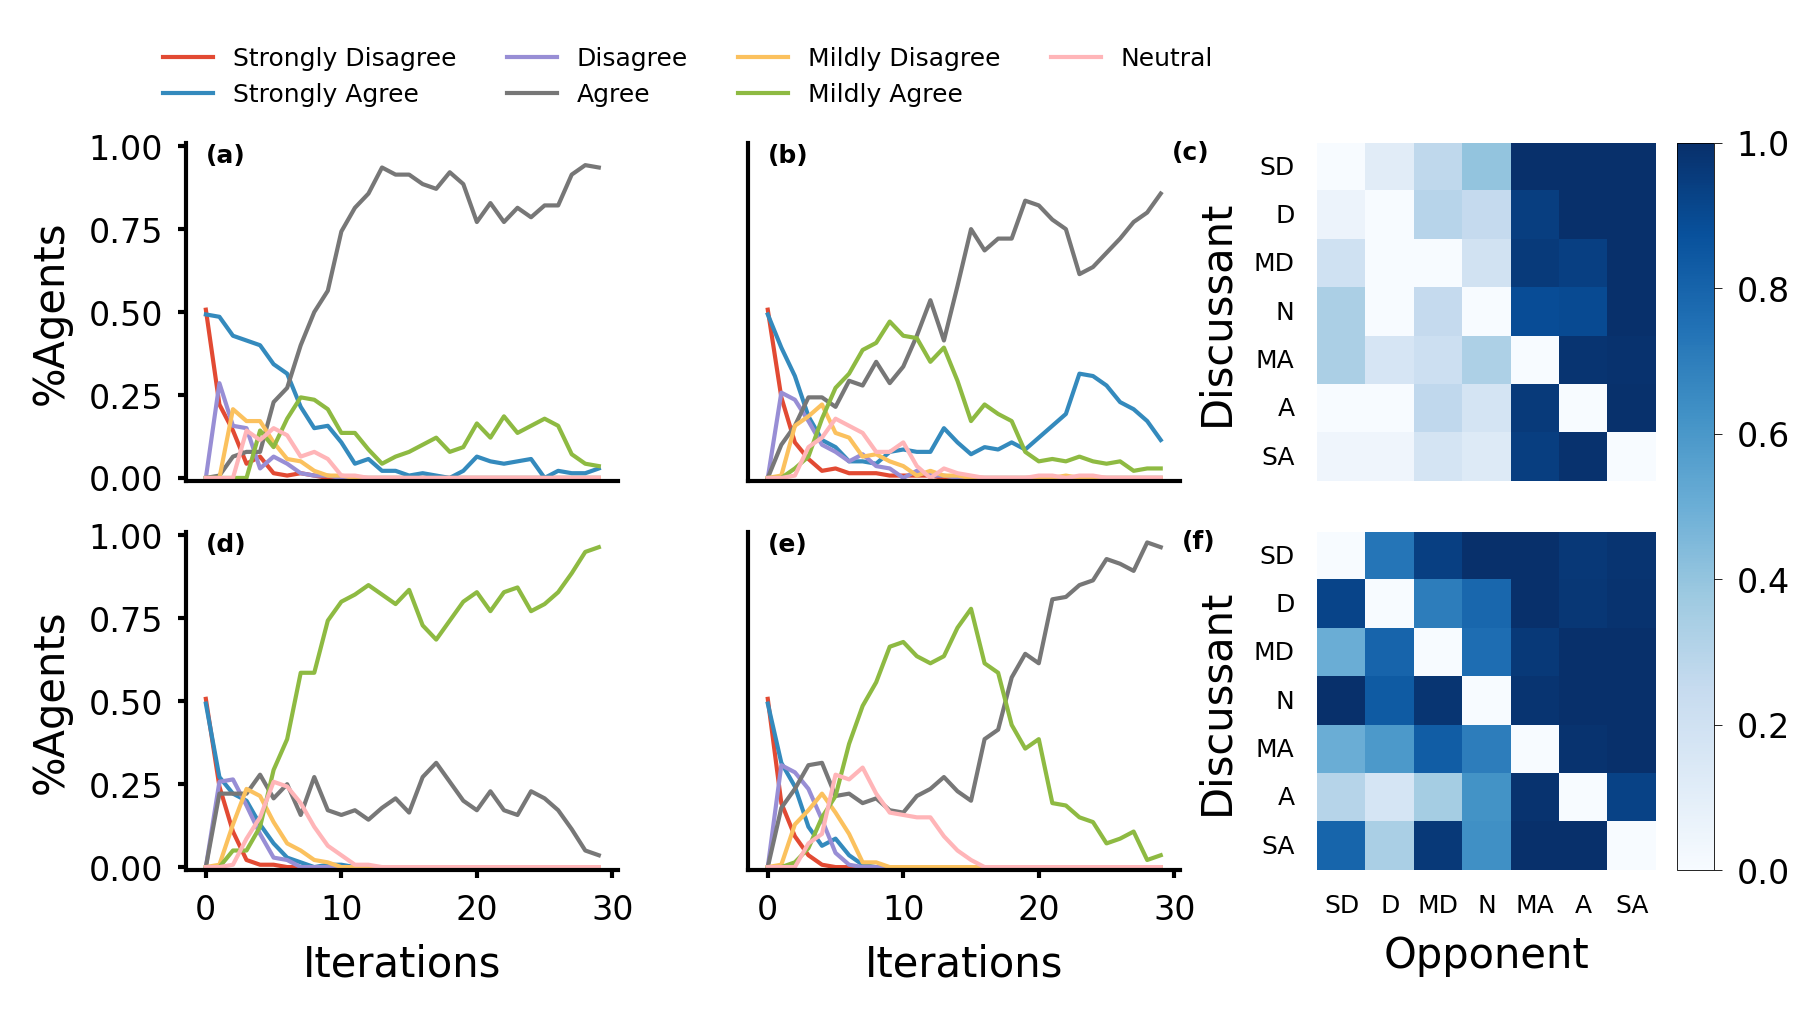

In [22]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Define the figure and GridSpec
fig = plt.figure(figsize=(width, height), dpi=300)
gs = GridSpec(2, 3, figure=fig, wspace=0.3, hspace=0.15)  # Adjust wspace for equal column spacing

# First row
ax1 = fig.add_subplot(gs[0, 0])
ot = OpinionTrends(path + f"results/theseus_same_mistral_0_polarized.jsonl")
ot.plot(ax=ax1)
ax1.text(0.0, 0.95, '(a)', fontweight='bold', fontsize=6)
ax1.set_xlabel("")  # X-axis label
ax1.set_xticks([])  # Remove x-axis ticks
#ax1.set_ylabel("")  # Y-axis label

ax2 = fig.add_subplot(gs[0, 1])
ot = OpinionTrends(path + f"results/theseus_different_mistral_0_polarized.jsonl")
ot.plot(ax=ax2)
ax2.text(0.0, 0.95, '(b)', fontweight='bold', fontsize=6)
ax2.set_xlabel("")  # X-axis label
ax2.set_ylabel("")  # Y-axis label
ax2.set_xticks([])  # Remove x-axis ticks
ax2.set_yticks([])  # Remove y-axis ticks

ax3 = fig.add_subplot(gs[0, 2])
sm = ShiftMatrix(f'../../results/shifts_data/theseus_same_mistral_polarized.json')
data = sm.get_data(d='accept')
sm.plot(d="accept", ax=ax3)
ax3.text(-0.43, 0.95, '(c)', fontweight='bold', fontsize=6, transform=ax3.transAxes)  # Add (c)
ax3.set_xlabel("")  # X-axis label
ax3.set_xticks([])  # Remove x-axis ticks

# Second row
ax4 = fig.add_subplot(gs[1, 0])
ot = OpinionTrends(path + f"results/theseus_same_llama3_0_polarized.jsonl")
ot.plot(ax=ax4)
ax4.text(0.0, 0.95, '(d)', fontweight='bold', fontsize=6)

ax5 = fig.add_subplot(gs[1, 1])
ot = OpinionTrends(path + f"results/theseus_different_llama3_1_polarized.jsonl")
ot.plot(ax=ax5)
ax5.text(0.0, 0.95, '(e)', fontweight='bold', fontsize=6)
ax5.set_ylabel("")
ax5.set_yticks([])

ax6 = fig.add_subplot(gs[1, 2])
sm = ShiftMatrix(f'../../results/shifts_data/theseus_same_llama3_polarized.json')
data = sm.get_data(d='accept')
sm.plot(d="accept", ax=ax6)
ax6.text(-0.4, 0.95, '(f)', fontweight='bold', fontsize=6, transform=ax6.transAxes)  # Add (f)

# Add a single colorbar for the last column
cax = ax6.get_images()[0]
cbar = plt.colorbar(cax, ax=[ax3, ax6], orientation="vertical", pad=0.05)
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.2)
cbar.ax.tick_params(labelsize=8, size=2, width=0.2)

# Add an additional axis forthe legend above the figure
legend_ax = fig.add_axes([0.125, 0.9, 0.5, 0.1])  # [left, bottom, width, height]
legend_ax.axis('off')  # Turn off the axis
handles, labels = ax1.get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='center', ncol=4, frameon=False)

plt.savefig(path+'figures/paper/polarized.pdf', bbox_inches='tight', dpi=300)


# Figure 8 (solo trend plots unbalanced)

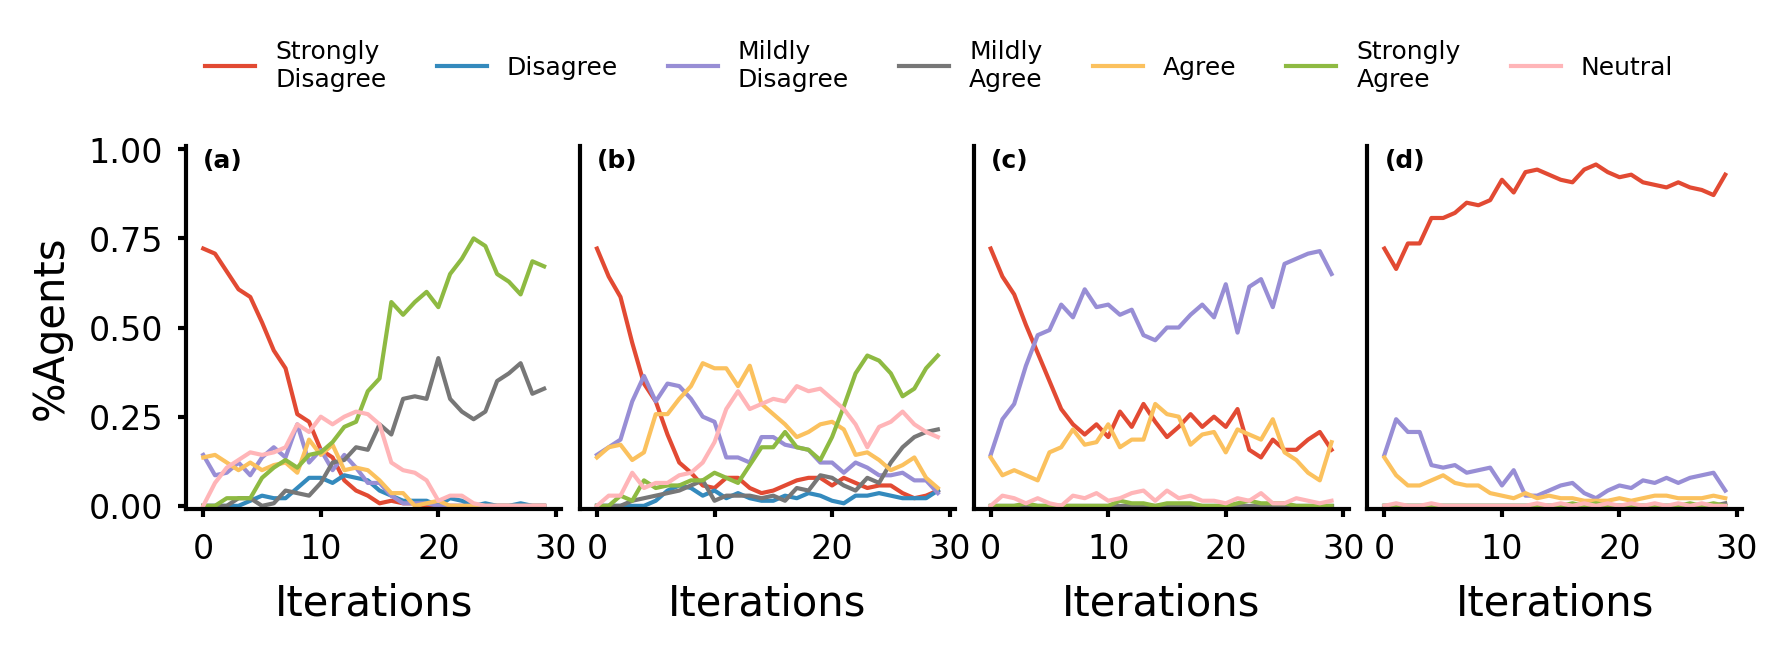

In [23]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

limit = 30

xticks = [0, 10, 20, 30]

cm = 1 / 2.54  # centimeters in inches

# Define the figure and GridSpec
fig = plt.figure(figsize=(width, height/2), dpi=300)
gs = GridSpec(1, 4, figure=fig, wspace=0.05, hspace=0.45)  # Adjust wspace for equal column spacing

# First row
ax1 = fig.add_subplot(gs[0, 0])
ot = OpinionTrends(path + f"results/theseus_same_mistral_0_unbalanced.jsonl")
ot.plot(ax=ax1, limit=limit)
ax1.text(0.0, 0.95, '(a)', fontweight='bold', fontsize=6)
ax1.set_xticks(xticks)

ax2 = fig.add_subplot(gs[0, 1])
ot = OpinionTrends(path + f"results/theseus_different_mistral_0_unbalanced.jsonl")
ot.plot(ax=ax2, limit=limit)
ax2.text(0.0, 0.95, '(b)', fontweight='bold', fontsize=6)
ax2.set_ylabel("")  # Y-axis label
ax2.set_yticks([])
ax2.set_xticks(xticks)

ax3 = fig.add_subplot(gs[0, 2])
ot = OpinionTrends(path + f"results/theseus_same_llama3_0_unbalanced.jsonl")
ot.plot(ax=ax3, limit=limit)
ax3.text(0.0, 0.95, '(c)', fontweight='bold', fontsize=6)
ax3.set_ylabel("")  # Y-axis label
ax3.set_yticks([])
ax3.set_xticks(xticks)



ax4 = fig.add_subplot(gs[0, 3])
ot = OpinionTrends(path + f"results/theseus_different_llama3_0_unbalanced.jsonl")
ot.plot(ax=ax4, limit=limit)
ax4.text(0.0, 0.95, '(d)', fontweight='bold', fontsize=6)
ax4.set_ylabel("")
ax4.set_yticks([])
ax4.set_xticks(xticks)

labels = [
    "Strongly\nDisagree",
    "Disagree",
    "Mildly\nDisagree",
    "Mildly\nAgree",
    "Agree",
    "Strongly\nAgree",
    "Neutral",
]

# Add an additional axis forthe legend above the figure
legend_ax = fig.add_axes([0.1, 1.0, 0.8, 0.1])  # [left, bottom, width, height]
legend_ax.axis('off')  # Turn off the axis
handles, _ = ax1.get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='center', ncol=7, frameon=False)

plt.savefig(path+'figures/paper/unbalanced_trends.pdf', bbox_inches='tight', dpi=300)


# Figure 9 (solo shift matrx unbalanced)

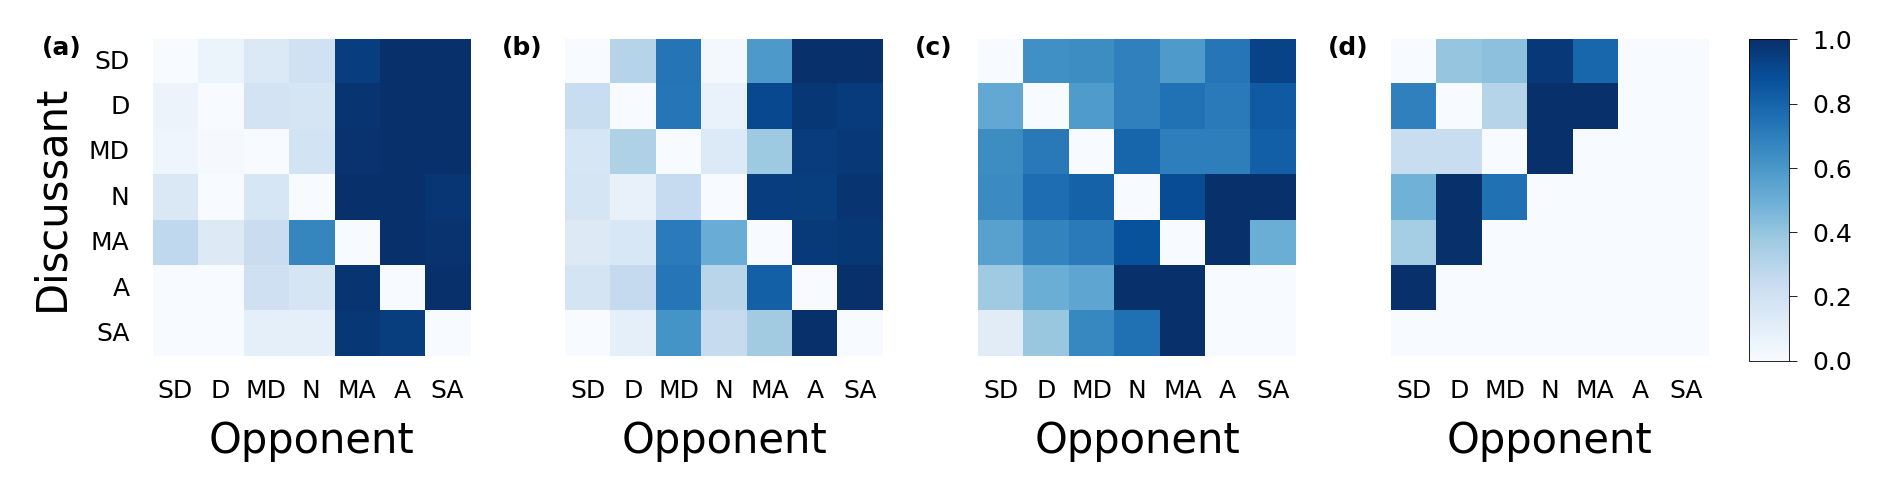

In [24]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

cm = 1 / 2.54  # centimeters in inches

# Define the figure and GridSpec
fig = plt.figure(figsize=(width, height/2), dpi=300)
gs = GridSpec(1, 4, figure=fig, wspace=0.3, hspace=0.0)  # Adjust wspace for equal column spacing

ax1 = fig.add_subplot(gs[0, 0])
sm = ShiftMatrix(f'../../results/shifts_data/theseus_same_mistral_unbalanced.json')
data = sm.get_data(d='accept')
sm.plot(d="accept", ax=ax1)
ax1.text(-0.35, 0.95, '(a)', fontweight='bold', fontsize=6, transform=ax1.transAxes)  # Add (f)

ax2 = fig.add_subplot(gs[0, 1])
sm = ShiftMatrix(f'../../results/shifts_data/theseus_different_mistral_unbalanced.json')
data = sm.get_data(d='accept')
sm.plot(d="accept", ax=ax2)
ax2.text(-0.2, 0.95, '(b)', fontweight='bold', fontsize=6, transform=ax2.transAxes)  # Add (f)
ax2.set_ylabel("")  # Y-axis label
ax2.set_yticks([])

ax3 = fig.add_subplot(gs[0, 2])
sm = ShiftMatrix(f'../../results/shifts_data/theseus_same_llama3_unbalanced.json')
data = sm.get_data(d='accept')
sm.plot(d="accept", ax=ax3)
ax3.text(-0.2, 0.95, '(c)', fontweight='bold', fontsize=6, transform=ax3.transAxes)  # Add (f)
ax3.set_ylabel("")  # Y-axis label
ax3.set_yticks([])

ax4 = fig.add_subplot(gs[0, 3])
sm = ShiftMatrix(f'../../results/shifts_data/theseus_different_llama3_unbalanced.json')
data = sm.get_data(d='accept')
sm.plot(d="accept", ax=ax4)
ax4.text(-0.2, 0.95, '(d)', fontweight='bold', fontsize=6, transform=ax4.transAxes)  # Add (f)
ax4.set_ylabel("")  # Y-axis label
ax4.set_yticks([])

# Add a single colorbar for all heatmaps
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.68])  # [left, bottom, width, height]
norm = plt.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.ax.tick_params(labelsize=6, size=2, width=0.2)
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.2)

plt.savefig(path+'figures/paper/unbalanced_acceptance_rates.pdf', bbox_inches='tight', dpi=300)